## Make Blobs

In [8]:
import torch
import matplotlib.pyplot as plt
from torch import nn
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

# 1. Data
n_samples = 1000
X, y = make_blobs(
    n_samples=n_samples,
    centers=5,
    cluster_std=1.8,
    random_state=42,
)

In [9]:
X[:3], y[:3]

(array([[  5.32423497,   3.07222403],
        [  2.10635779,   0.57309965],
        [ -5.49056951, -12.00748631]]),
 array([1, 1, 2]))

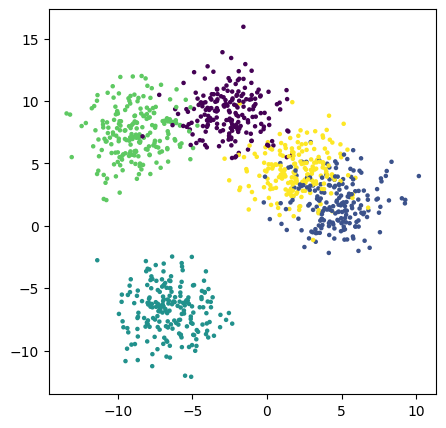

In [10]:
plt.figure(figsize=(5, 5))

plt.scatter(X[:, 0], X[:, 1], c=y, s=5)
plt.show()

In [11]:
X = torch.from_numpy(X).float()
y = torch.from_numpy(y).long()      # CrossEntropyLoss requires long (class labels)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2. Accuracy function
def accuracy_fn(y_pred, y_true):
    # For a multiclass problem, the model returns the logits in the form of a matrix [N,C]:
    # N = number of samples in the batch, C = number of classes (5)

    y_pred_class = y_pred.argmax(dim=1)
    correct = torch.eq(y_true, y_pred_class).sum().item()
    return (correct / len(y_pred)) * 100

# 3. Model
model = nn.Sequential(
    nn.Linear(2, 32), 
    nn.ReLU(), 
    nn.Linear(32, 32), 
    nn.ReLU(), 
    nn.Linear(32, 5)
)

# 4. Loss i optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters(), lr=0.01)

# 5. Training loop
epochs = 300

for epoch in range(epochs):
    model.train()

    y_logits = model(X_train)
    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_logits, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.inference_mode():
        test_logits = model(X_test)
        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(test_logits, y_test)

    if epoch % 20 == 0:
        print(
            f"Epoch {epoch} | Loss {loss:.4f}, Acc {acc:.2f}% | Test {test_loss:.4f}, Test Acc {test_acc:.2f}%"
        )

Epoch 0 | Loss 1.5918, Acc 14.88% | Test 1.2121, Test Acc 57.00%
Epoch 20 | Loss 0.2714, Acc 88.75% | Test 0.2712, Test Acc 87.00%
Epoch 40 | Loss 0.2360, Acc 90.62% | Test 0.2436, Test Acc 89.00%
Epoch 60 | Loss 0.2205, Acc 91.12% | Test 0.2362, Test Acc 89.50%
Epoch 80 | Loss 0.2136, Acc 91.50% | Test 0.2347, Test Acc 89.50%
Epoch 100 | Loss 0.2102, Acc 91.88% | Test 0.2346, Test Acc 90.00%
Epoch 120 | Loss 0.2083, Acc 92.00% | Test 0.2347, Test Acc 90.00%
Epoch 140 | Loss 0.2069, Acc 91.88% | Test 0.2347, Test Acc 90.00%
Epoch 160 | Loss 0.2056, Acc 92.00% | Test 0.2347, Test Acc 89.50%
Epoch 180 | Loss 0.2045, Acc 91.75% | Test 0.2372, Test Acc 88.50%
Epoch 200 | Loss 0.2028, Acc 92.25% | Test 0.2345, Test Acc 89.50%
Epoch 220 | Loss 0.2014, Acc 92.12% | Test 0.2375, Test Acc 88.50%
Epoch 240 | Loss 0.2010, Acc 92.00% | Test 0.2359, Test Acc 89.50%
Epoch 260 | Loss 0.1973, Acc 92.00% | Test 0.2388, Test Acc 89.00%
Epoch 280 | Loss 0.1959, Acc 92.25% | Test 0.2376, Test Acc 90.00%


In [ ]:
# 6. Visualization of decision boundaries
import numpy as np

def plot_decision_boundary(model, X, y):
    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
        )
    
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()],
                        dtype=torch.float32
                        )
    